# Hierarchical Zooplankton Classification — Progress Report

## Objective

The objective of this project is to investigate hierarchical image classification methods for accurately classifying Zooplankton images into their corresponding classes. Our collaborators, the Ontario Ministry of Resources, are interested in different methods in conducting hierarchical classification. Due to the lack of research in this area, any findings would be very useful for Sofia for future references. 

## Motivation

Flat classifiers treat all labels as independent categories, ignoring the biological structure that links them (e.g., Cyclopoid and Calanoid are both Copepods, which are both Zooplankton). A hierarchical model **enforces taxonomic constraints**: a prediction must be consistent at every level of the tree — you cannot predict a sample is Copepoda at level 2 but Non-Zooplankton at level 1.

## What this report covers

1. Dataset overview and hierarchy structure
2. The HardRouter architecture (EfficientNet-B0 + tree-structured experts)
3. Training setup and results
4. Per-level evaluation: accuracy, F1, confusion matrices
5. Cross-level summary and discussion

---
## 1. Dataset Overview

We will be using two datasets as mentioned in Sofia's HierNet repository. The first dataset is the Zooplankton-MNR. This dataset is collected by the Ontario Ministry of Resources and manually labelled. This is the main dataset that will be used for our model training. The WHOI-data will then be used to test our models robustness against different hierarchies.

| Property | Value |
|---|---|
| Datasets | Plankton-WHOI (marine), Zooplankton-MNR (freshwater) |
| Image format | 64×64 TIFF, grayscale |
| Max samples per class | 10,000 |
| Leaf classes | 13 |
| Train / Val / Test split | 70% / 10% / 20% |

### 3-Level Hierarchy

```
root
├── Zoop-yes
│   ├── Copepoda  → [Cyclopoid, Calanoid, Harpacticoid, Nauplius_Copepod]
│   ├── Cladocera → [Bosminidae, Daphnia]
│   └── Rotifer
└── Zoop-No
    ├── Debris
    ├── Bubbles
    ├── Exoskeleton
    └── Fiber_Squiggly
```

Level 1 is binary (Zooplankton vs. Non-Zooplankton). Level 2 classifies into Orders. Level 3 classifies into Species. Note that Rotifer, Debris, Bubbles, Exoskeleton, and Fiber_Squiggly are leaf nodes at level 2 (they have no finer subdivision in this dataset).

**Total dataset: 59,810 samples across 3 levels** (1,491 non-leaf samples removed, leaves only)

#### Level 1 — Zooplankton vs. Non-Zooplankton

| Class | Type | Count | Proportion |
|---|---|---|---|
| Zoop-yes | Parent | 37,350 | 62% |
| Zoop-No | Parent | 22,460 | 38% |

#### Level 2 — Order

| Class | Type | Count | Proportion |
|---|---|---|---|
| Copepoda | Parent | 27,778 | 46% |
| Cladocera | Parent | 6,522 | 11% |
| Debris | Leaf | 10,000 | 17% |
| Rotifer | Leaf | 3,050 | 5% |
| Bubbles | Leaf | 4,858 | 8% |
| Exoskeleton | Leaf | 1,147 | 2% |
| Fiber_Squiggly | Leaf | 6,455 | 11% |

#### Level 3 — Species

| Class | Type | Count | Proportion |
|---|---|---|---|
| Cyclopoid | Leaf | 10,000 | 17% |
| Calanoid | Leaf | 10,000 | 17% |
| Harpacticoid | Leaf | 1,728 | 3% |
| Nauplius_Copepod | Leaf | 6,050 | 10% |
| Bosminidae | Leaf | 3,023 | 5% |
| Daphnia | Leaf | 3,499 | 6% |

---
## 2. Current Approach: HardRouter

### Why HardRouter?

Three classifier paradigms exist for hierarchical classification:

| Approach | How it works | Problem |
|---|---|---|
| Flat | Single softmax head over all 13 classes | Ignores hierarchy — no notion of taxonomic relationships |
| Multi-task (Sofia's approach) | Separate softmax head per level, trained jointly | Heads are independent — can contradict each other (e.g., predict Copepoda at L2 but Zoop-No at L1) |
| **HardRouter** | Routes each sample through the tree one decision at a time | Structurally consistent by construction — leaf prediction always implies a valid path from root |

**HardRouter** enforces that every prediction follows a valid root-to-leaf path. During **training**, routing is *soft* (product of softmax probabilities, differentiable). During **inference**, routing is *hard* (greedy argmax at each internal node from root to leaf, ensures the hierarchical structure).

---

### The Backbone: EfficientNet-B0

EfficientNet is a family of convolutional neural networks introduced by Tan & Le (2019). The key innovation is **compound scaling**: rather than scaling only depth (more layers), width (more channels), or resolution (larger input) independently, EfficientNet scales all three dimensions simultaneously using a fixed ratio derived from neural architecture search. This achieves better accuracy per parameter than prior architectures.

**B0** is the base (smallest) model in the family:

| Property | Value |
|---|---|
| Parameters | ~5.3M (vs. ResNet-50 at 25M, VGG-16 at 138M) |
| Output feature size | 1280-dimensional vector (after global average pooling) |
| Pretrained on | ImageNet-1K (1.28M images, 1000 classes) |
| Input | Any resolution; we feed 64×64 TIFFs directly |

We remove EfficientNet-B0's original classification head (the final linear layer over 1000 ImageNet classes). The remaining convolutional trunk acts as a **shared feature extractor**: for any input image, it produces a single 1280-dimensional vector `f` encoding the visual content. All experts in the tree then operate on this same `f`.

#### Inside EfficientNet: MBConv blocks

EfficientNet's building block is the **MBConv** (Mobile Inverted Bottleneck Convolution), adapted from MobileNetV2. Each block applies:

1. **Expand** — 1×1 pointwise conv to increase channels by an expansion factor *t* (typically 6×)
2. **Depthwise conv** — 3×3 or 5×5 convolution applied *per channel* (much cheaper than standard conv)
3. **Squeeze-and-Excitation (SE)** — global average pool the spatial dimensions → two small FC layers → rescale each channel by a learned weight. This lets the network dynamically emphasize the most discriminative feature channels for a given image (e.g., emphasize texture channels for a Copepoda, emphasize shape channels for a Bubble).
4. **Project** — 1×1 pointwise conv to reduce back to the output channel count
5. **Residual skip** — add input to output if shapes match (same as ResNet)

The SE module is particularly useful for zooplankton: different species are distinguished by different visual cues (body shape, appendage texture, transparency), and SE allows the network to weight those cues differently per image rather than applying a fixed filter bank to everything.

---

### Experts: One Linear Layer per Internal Node

Each **internal node** in the taxonomy tree (nodes that have children) gets its own `Expert` — a single linear layer that maps the shared 1280-dim feature vector to logits over that node's children:

```python
class Expert(nn.Module):
    def __init__(self, in_features: int, n_children: int):
        super().__init__()
        self.fc = nn.Linear(in_features, n_children)

    def forward(self, x):
        return self.fc(x)  # (batch, n_children)
```

Our tree has **5 internal nodes**, one Expert each:

| Expert node | Children | Expert output size |
|---|---|---|
| root | Zoop-yes, Zoop-No | 2 |
| Zoop-yes | Copepoda, Cladocera, Rotifer | 3 |
| Zoop-No | Debris, Bubbles, Exoskeleton, Fiber_Squiggly | 4 |
| Copepoda | Cyclopoid, Calanoid, Harpacticoid, Nauplius_Copepod | 4 |
| Cladocera | Bosminidae, Daphnia | 2 |

All 5 experts share the same backbone features `f`. Each expert independently specializes: the root expert learns to separate zooplankton from non-zooplankton, the Copepoda expert learns to distinguish copepod species, and so on.

---

### Soft Routing (Training)

During training, **all 5 experts run in parallel** on the same feature vector. No sample is committed to a single path — the model maintains a probability distribution over *all* root-to-leaf paths simultaneously.

For each internal node `n` with `k` children, the expert computes a **conditional probability distribution** over its children via softmax:

```
logits_n    = Expert_n(f)               # raw scores, shape: (batch, k)
P(c_i | n)  = softmax(logits_n)_i       # probability of child i given parent n
```

The **absolute probability of a leaf node** `l` is then the product of all conditional probabilities along its root-to-leaf path. For example:

```
P(Cyclopoid) = P(Zoop-yes  | root)     × P(Copepoda | Zoop-yes) × P(Cyclopoid | Copepoda)
P(Daphnia)   = P(Zoop-yes  | root)     × P(Cladocera | Zoop-yes) × P(Daphnia | Cladocera)
P(Bubbles)   = P(Zoop-No   | root)     × P(Bubbles   | Zoop-No)
P(Rotifer)   = P(Zoop-yes  | root)     × P(Rotifer   | Zoop-yes)
```

This computation has two important properties:

**1. All 13 leaf probabilities sum to 1.**  
At every node, the softmax over children sums to 1, and each node's probability mass is partitioned across its children. The total probability across all leaves therefore sums to exactly 1, forming a valid probability distribution.

**2. The computation is fully differentiable.**  
Softmax and multiplication are both differentiable operations. Gradients from the leaf-level loss flow back through every multiplication in the path product, updating *every* expert simultaneously — the root expert learns from leaf-level errors, not just from a direct level-1 supervision signal.

Visually:
```
                     [root expert]
                    /              \
          P(Zoop-yes)          P(Zoop-No)
          /    |    \          /  |   |   \
      Cop.  Clad. Rot.    Deb. Bub. Exo. Fib.
      / |  \ \  /
    Cy. Ca. Ha. Na.  Bo. Da.
```
Each edge weight is a conditional probability from a softmax. Each leaf's absolute probability is the product of all edge weights on its path from root.

---

### Hard Routing (Inference)

At inference time, we switch to **hard routing**: at each internal node, take the argmax of that node's expert and follow only that branch greedily:

```python
node = root
while node has children:
    logits   = Expert_node(f)
    child_idx = argmax(logits)
    node     = node.children[child_idx]
prediction = node  # always a valid leaf
```

Hard routing is **structurally consistent by construction**: the final leaf was reached by a chain of valid parent→child decisions, so the level-1, level-2, and level-3 predictions derived from that path are never contradictory. This is the core guarantee of the HardRouter approach — it is architecturally impossible to produce a hierarchy mismatch.

**Soft vs. hard at inference:**  
Soft routing picks `argmax` over all 13 leaf probabilities, while hard routing greedily follows argmax at each node. These can differ: suppose P(Zoop-No)=0.51 (root goes right), but among zooplankton leaves the model is very confident — the top zooplankton leaf might have a higher absolute probability than any non-zooplankton leaf. Soft routing would pick that zooplankton leaf despite P(Zoop-No) > 0.5; hard routing would correctly commit to Zoop-No first. Hard routing respects the hierarchical structure more strictly.

---
## 3. Code Architecture

### `hierroute` module

| File | Contents |
|---|---|
| `constants.py` | Class names, hierarchy adjacency graph, data paths, `SEED=666` |
| `hierarchy.py` | `Node` and `Hierarchy` tree classes; `get_path_to_root()`, `subtree_leaves()`, `descendants()`, `get_leaf_index()` |
| `data_setup.py` | `ImageDataset` (loads 64×64 TIFFs, applies augmentation); `HierImageDataset` (wraps with per-node targets and masks for hierarchical supervision) |

### `hardrouter.ipynb` — key classes

| Class | Role |
|---|---|
| `Expert` | Linear layer for a single internal node; outputs logits over its children |
| `HierRouteNet` | EfficientNet-B0 backbone + one `Expert` per internal node; implements soft/hard routing |
| `Trainer` | Training loop with early stopping, gradient clipping, best-model saving |
| `Visualize` | Generates all evaluation plots saved in `efficient_net_2026-03-06/` |

The `hierarchy.py` utility methods support this: `get_path_to_root()` returns the ordered list of ancestors for computing path products; `subtree_leaves()` and `descendants()` are used to build the leaf-probability matrix and the evaluation masks.

---
## 4. Training Setup

| Hyperparameter | Value |
|---|---|
| Optimizer | Adam, lr=3e-4 |
| Scheduler | CosineAnnealingLR, T_max=50 |
| Loss | BCE on leaf probabilities only (see below) |
| Early Stopping | patience=15, delta=0.0005 (monitors val accuracy) |
| Gradient Clipping | max_norm=1.0 |
| Batch size | 64 |
| Max epochs | 20 |
| Device | MPS (Apple Silicon) with CUDA/CPU fallback |
| Reproducibility | `set_seed(666)` — Python random, numpy, torch, cuda seeds; `cudnn.deterministic=True` |

### Loss function

Only leaf probabilities are supervised directly:

```python
loss = (BCE(leaf_probs, targets) * leaf_mask).sum(dim=1) / leaf_mask.sum()
```

`leaf_mask` zeros out loss for non-leaf positions. Because leaf probabilities are products of all conditionals along their paths, the loss backpropagates gradients through every expert simultaneously — no per-level loss weighting is needed.

### Data Augmentation

- RandomHorizontalFlip
- RandomVerticalFlip
- RandomRotation(180°)
- Padding (5px)

### Model saving

State dict saved to `best_model.pt` whenever val accuracy improves. `training_info.json` stores hyperparams and per-epoch metrics.

---
## 5. Training Results

Training ran for **20 epochs** (no early stop triggered). Best checkpoint at **epoch 18**.

| Metric | Epoch 1 | Epoch 20 | Best (Epoch 18) |
|---|---|---|---|
| Train Accuracy | ~50.6% | ~83.0% | 82.65% |
| Val Accuracy | ~59.4% | ~82.4% | **82.36%** |

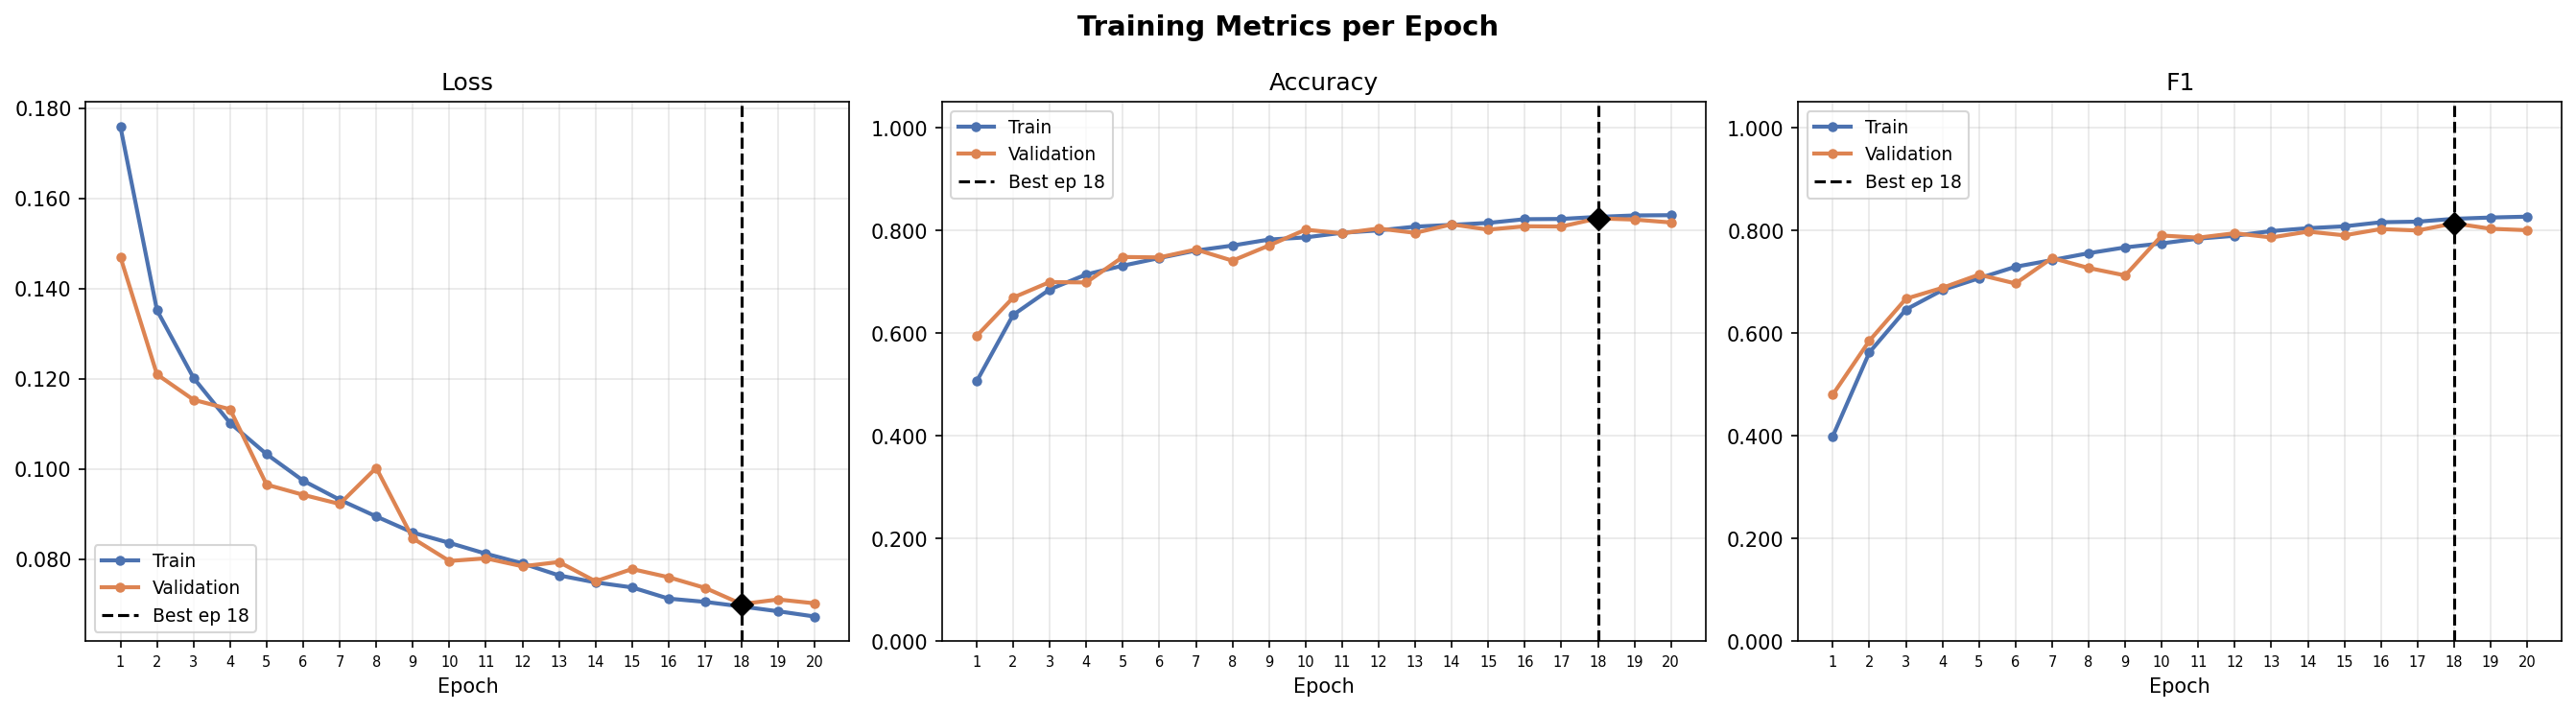

In [4]:
from IPython.display import Image, display

display(Image('efficient_net_2026-03-06/train_metrics.png'))

The plot shows three bar charts (loss, accuracy, F1) for each epoch, with training (blue) and validation (orange) bars side by side. The best epoch is outlined in black. The model converged steadily: loss decreased consistently while accuracy and F1 climbed from ~50% to ~83% over 20 epochs, with train and val tracking closely — no significant overfitting.

---
## 6. Evaluation Methodology

**Per-level alignment**: at level `k`, a sample is only evaluated if its true label has depth ≥ k. This means:
- Level 1: all 11,962 test samples evaluated (binary: Zooplankton vs. Non-Zooplankton)
- Level 2: all 11,962 samples evaluated (Order classification)
- Level 3: only 6,926 / 11,962 samples evaluated — those belonging to species with a finer subdivision (Cyclopoid, Calanoid, Harpacticoid, Nauplius_Copepod, Bosminidae, Daphnia)

**Macro averaging** is used for all reported metrics (accuracy, F1, precision, recall) — each class contributes equally regardless of size, preventing large classes from dominating the numbers.

**Structural consistency check**: all 11,962 predictions were verified to follow valid hierarchy paths. Result: **0 mismatches** since the HardRouter architecture guarantees structural consistency by construction.

---
## 7. Results: Level 1 — Zooplankton vs. Non-Zooplankton

| Metric | Value |
|---|---|
| Accuracy | **98.66%** |
| Macro F1 | **98.56%** |
| Precision | 98.65% |
| Recall | 98.47% |
| N Samples | 11,962 |

Near-perfect binary classification. Both classes perform strongly: Zoop-yes (F1 98.94%, n=7,563) and Zoop-No (F1 98.17%, n=4,399). This suggests EfficientNet-B0 easily separates the zooplankton vs. non-zooplankton visual distinction.

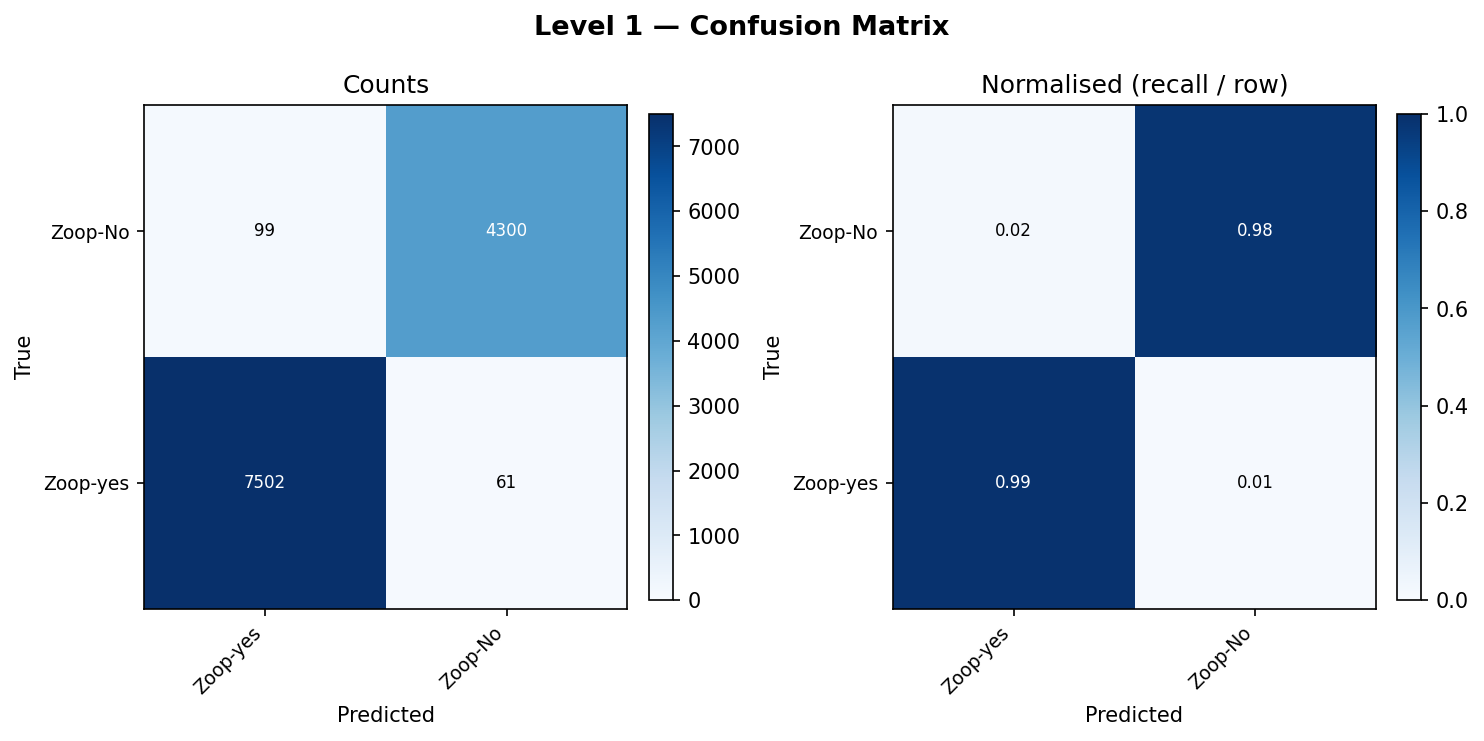

In [13]:
display(Image('efficient_net_2026-03-06/confusion_matrix_level1.png', width=1000))

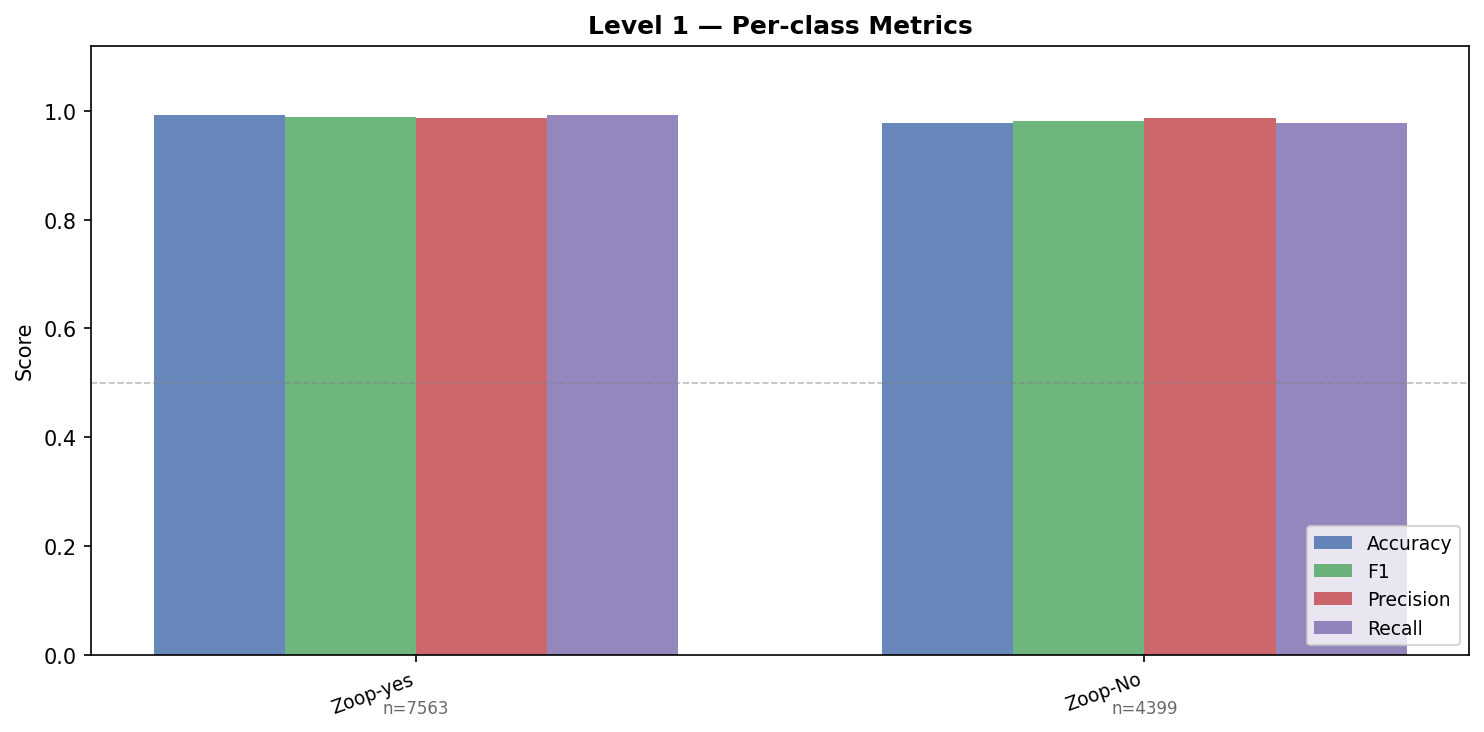

In [31]:
display(Image('efficient_net_2026-03-06/class_metrics_level1.png', width=600))

The confusion matrix shows minimal off-diagonal entries — most misclassifications are Non-Zooplankton predicted as Zooplankton (false positives). The class metrics bar chart confirms both classes achieve >97% on all metrics.

---
## 8. Results: Level 2 — Order Classification

| Class | N Samples | Accuracy | F1 | Notes |
|---|---|---|---|---|
| Copepoda | 5,633 | 98.08% | 96.78% | Strong — largest class |
| Bubbles | 998 | 98.20% | 97.95% | Strong — visually distinct |
| Cladocera | 1,293 | 89.02% | 91.97% | Good |
| Rotifer | 637 | 87.60% | 89.78% | Good |
| Debris | 1,924 | 66.58% | 69.22% | Weak — visually ambiguous |
| Fiber_Squiggly | 1,247 | 69.29% | 66.11% | Weak — confused with Debris |
| Exoskeleton | 230 | 61.74% | 63.96% | Weakest — small class, ambiguous morphology |

**Overall: Acc 87.79%, Macro F1 82.25%**

Copepoda and Bubbles are near-perfect. Debris, Fiber_Squiggly, and Exoskeleton underperform — likely because (a) Debris/Fiber/Exoskeleton are visually similar broken/irregular particles, and (b) Exoskeleton has only 230 test samples.

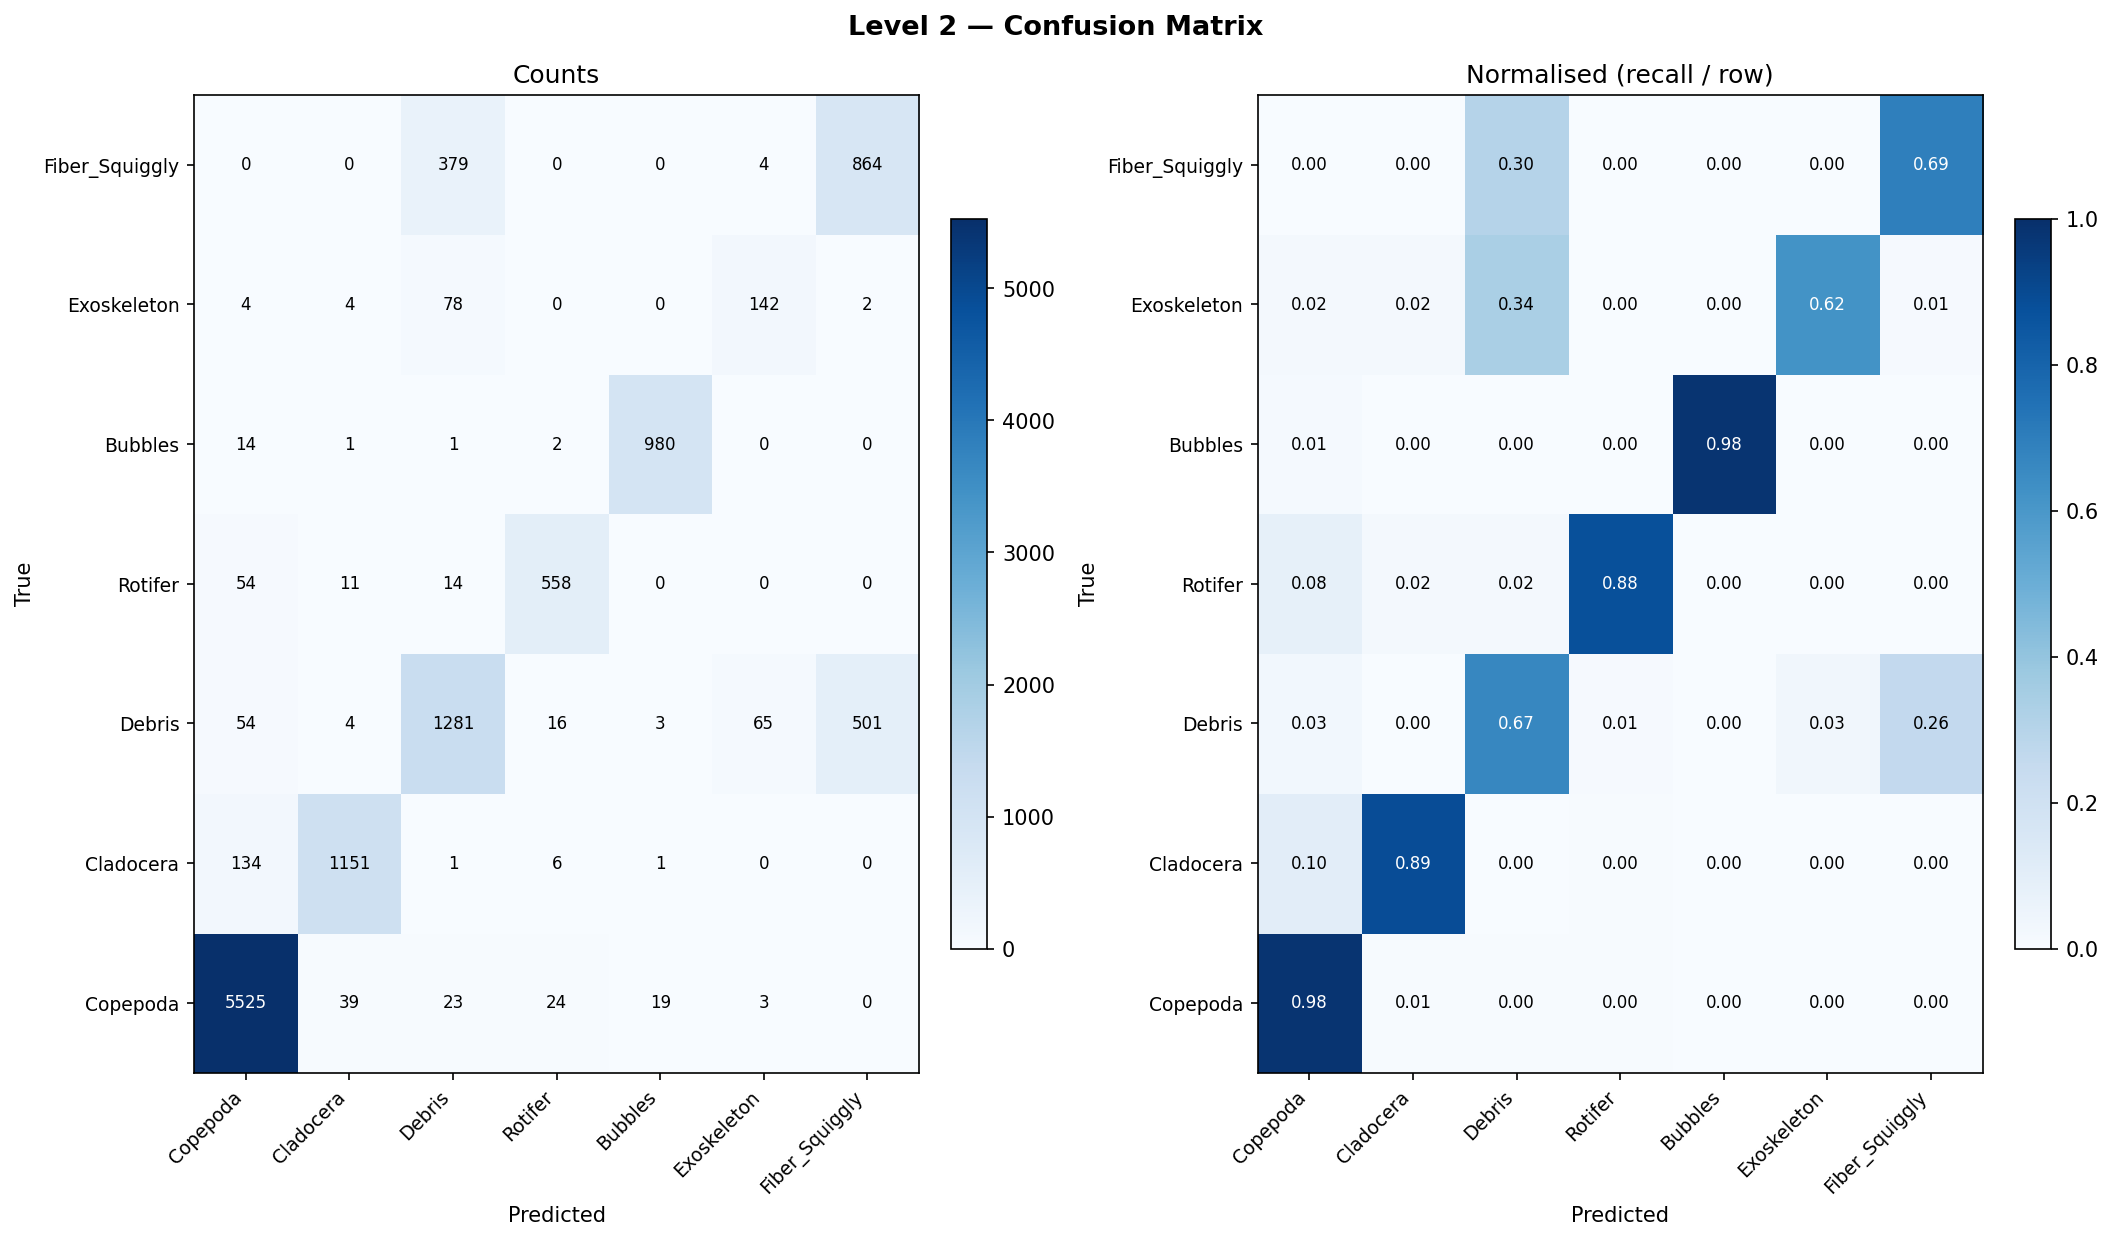

In [37]:
display(Image('efficient_net_2026-03-06/confusion_matrix_level2.png', width=1000))

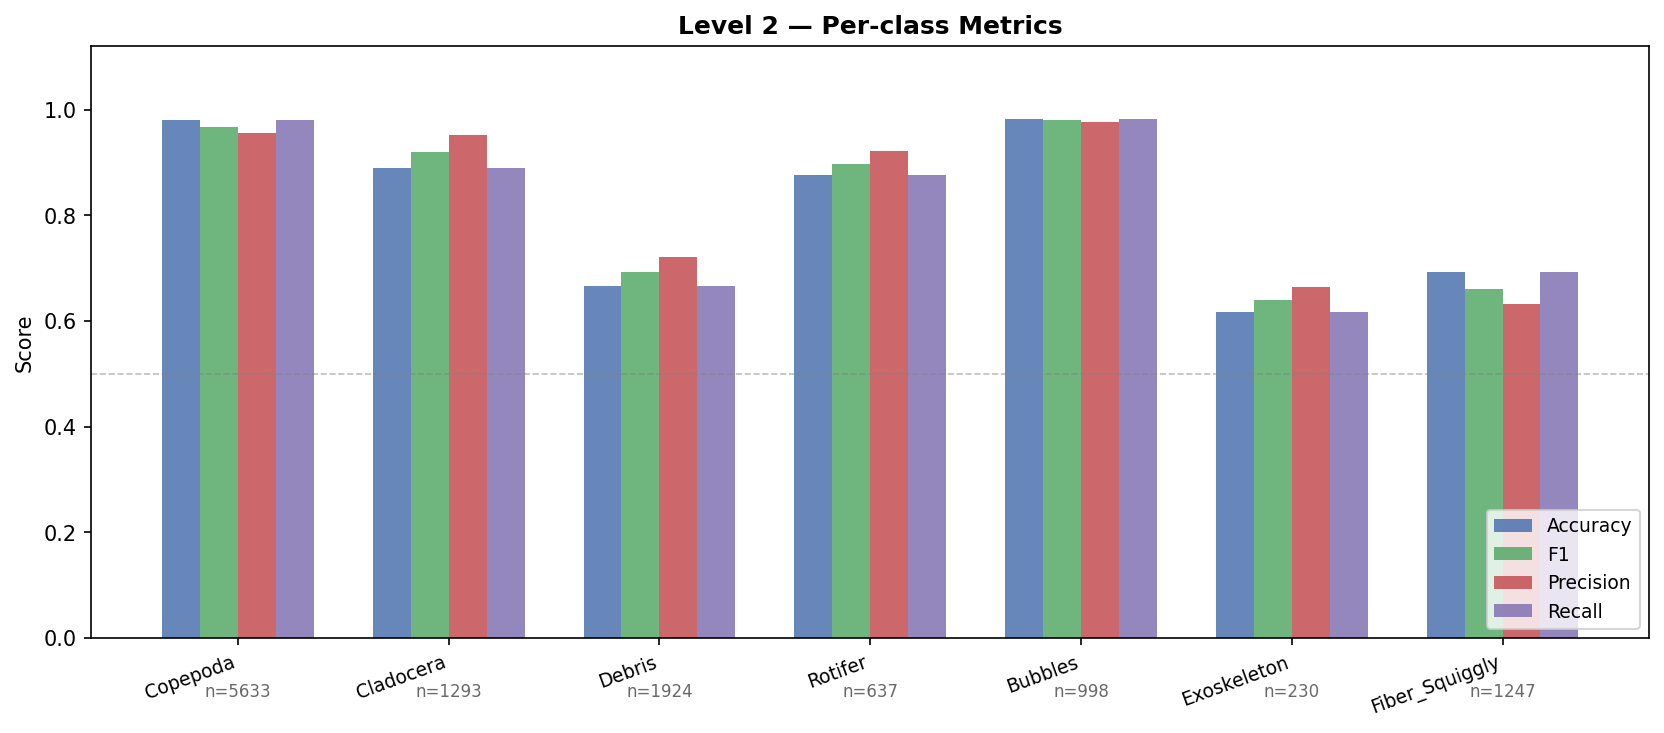

In [17]:
display(Image('efficient_net_2026-03-06/class_metrics_level2.png', width=800))

The confusion matrix reveals the main failure mode: Debris, Fiber_Squiggly, and Exoskeleton are confused with each other. These three non-zooplankton classes share similar irregular, elongated morphology. Copepoda (the largest class) and Bubbles (spherical, visually distinct) show tight diagonal clusters with minimal confusion.

---
## 9. Results: Level 3 — Species Classification

| Class | N Samples | Accuracy | F1 | Notes |
|---|---|---|---|---|
| Nauplius_Copepod | 1,222 | 95.09% | 95.09% | Best — morphologically distinct larval stage |
| Bosminidae | 599 | 89.15% | 92.23% | Strong |
| Cyclopoid | 1,995 | 88.82% | 87.36% | Good — largest species class |
| Calanoid | 2,055 | 87.79% | 88.06% | Good |
| Daphnia | 694 | 87.03% | 91.17% | Good |
| Harpacticoid | 361 | 71.19% | 74.06% | Weakest — small class, morphologically similar to other copepods |

**Overall: Acc 88.55%, Macro F1 88.00%** (evaluated on 6,926 samples)

Nauplius_Copepod is the easiest: larval copepods have a very distinct oval morphology. Harpacticoid is the hardest: only 361 test samples, and benthic copepods share body plan features with Cyclopoid and Calanoid.

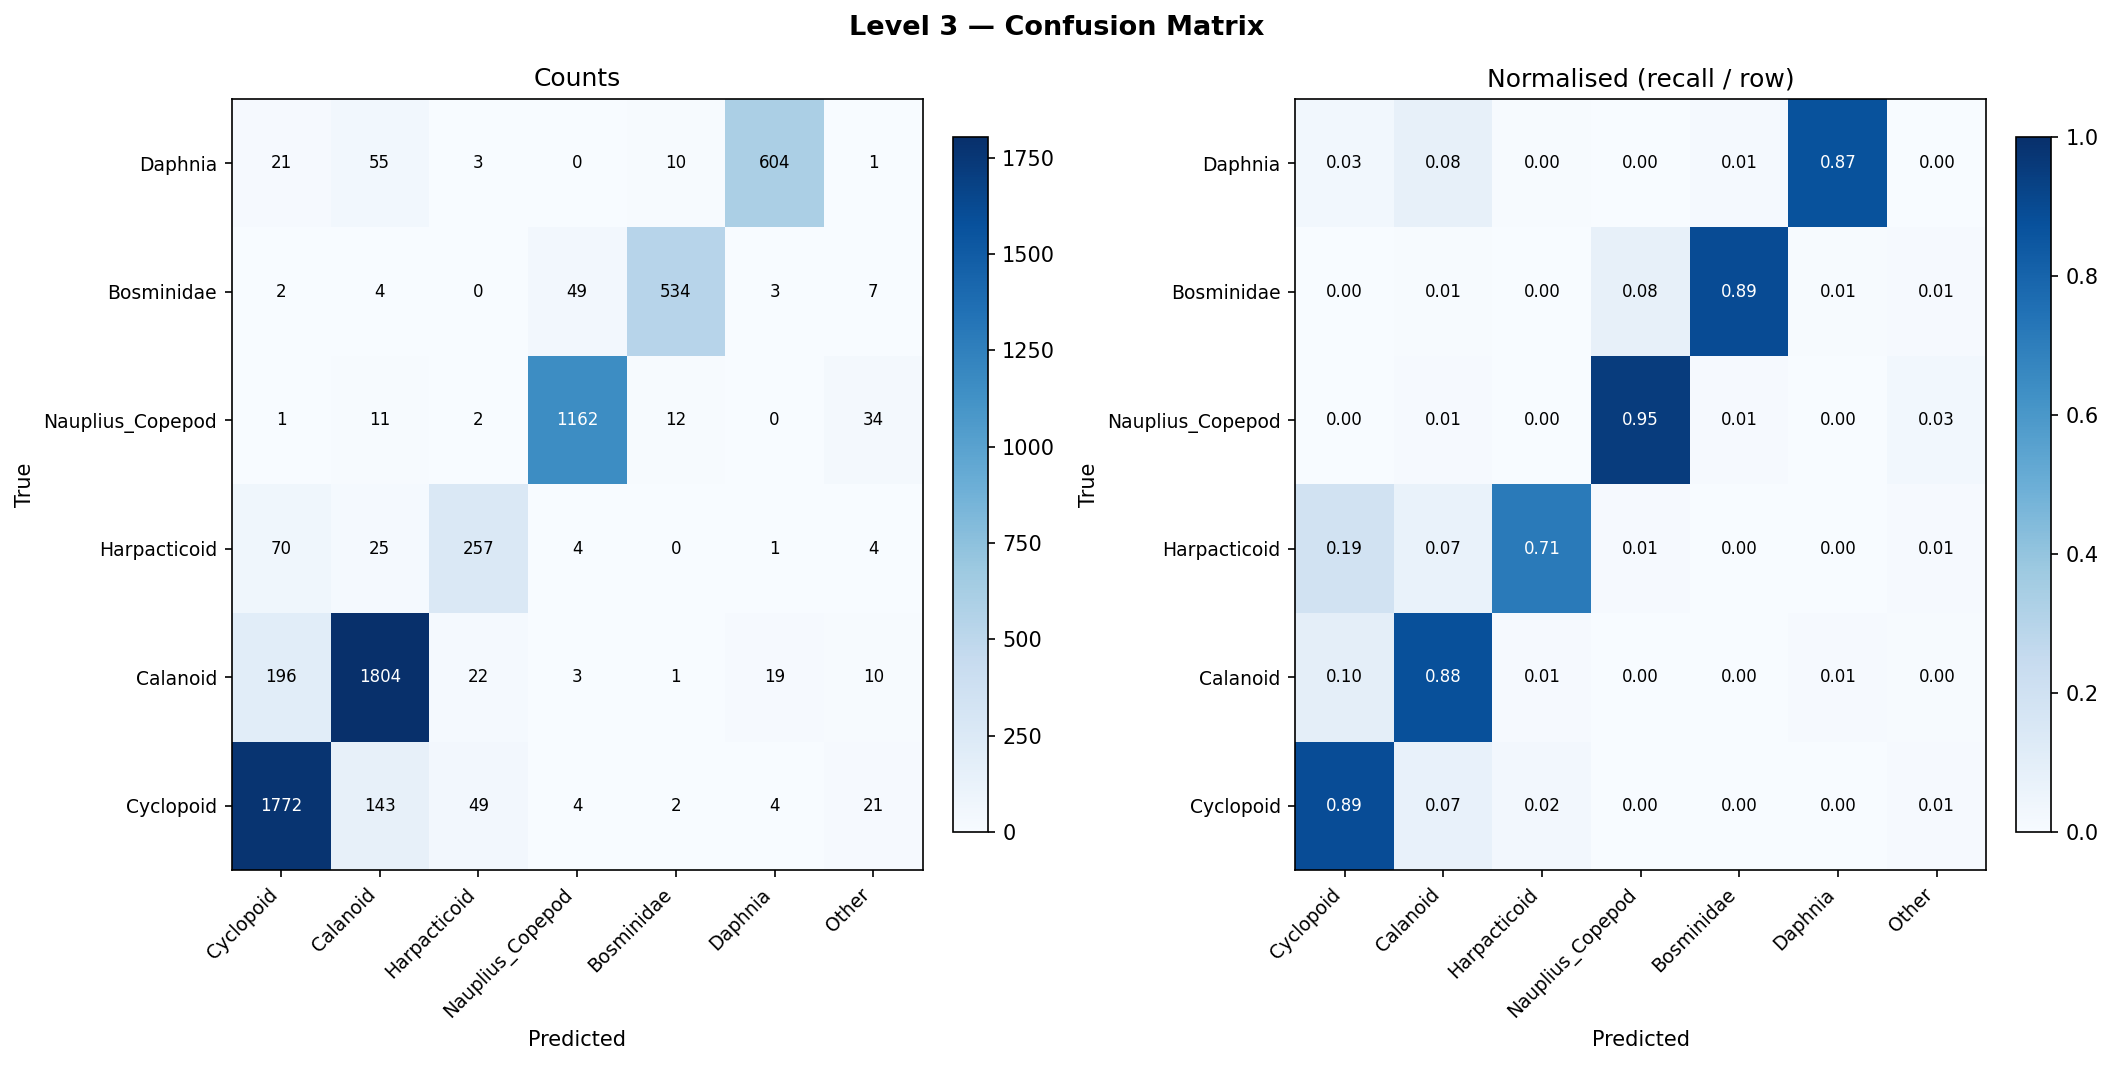

In [18]:
display(Image('efficient_net_2026-03-06/confusion_matrix_level3.png', width=1000))

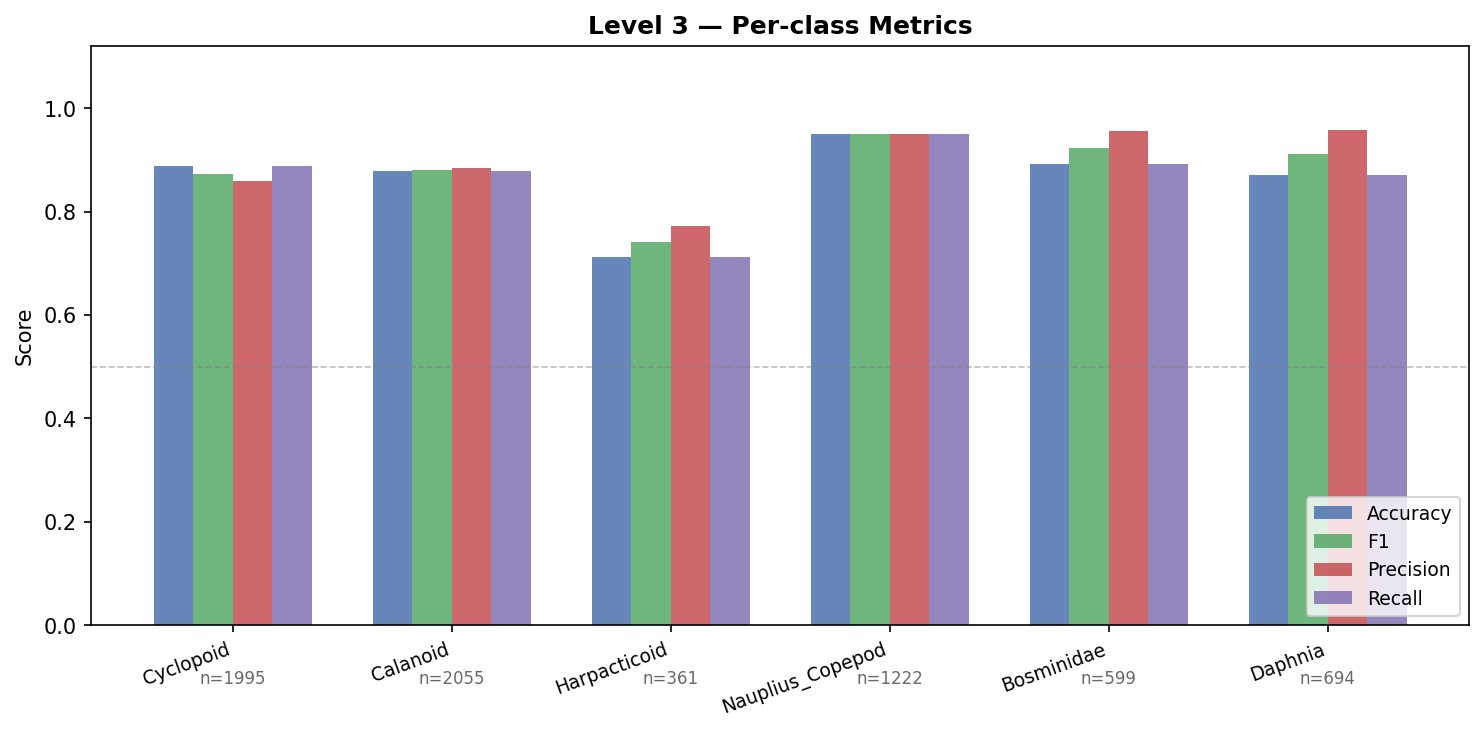

In [19]:
display(Image('efficient_net_2026-03-06/class_metrics_level3.png', width=800))

The level-3 confusion matrix may include an **"Other" column** representing predictions that were routed to the wrong subtree at level 2 (e.g., a Cyclopoid sample predicted as Non-Zooplankton at level 1 — the hard router cannot reach any level-3 class). This demonstrates how errors propagate down the tree: a wrong decision at an upper node forecloses correct predictions at lower nodes.

Within the Copepoda subtree, Harpacticoid is most often confused with Cyclopoid and Calanoid — all three share the elongated segmented body plan.

---
## 10. Cross-Level Summary

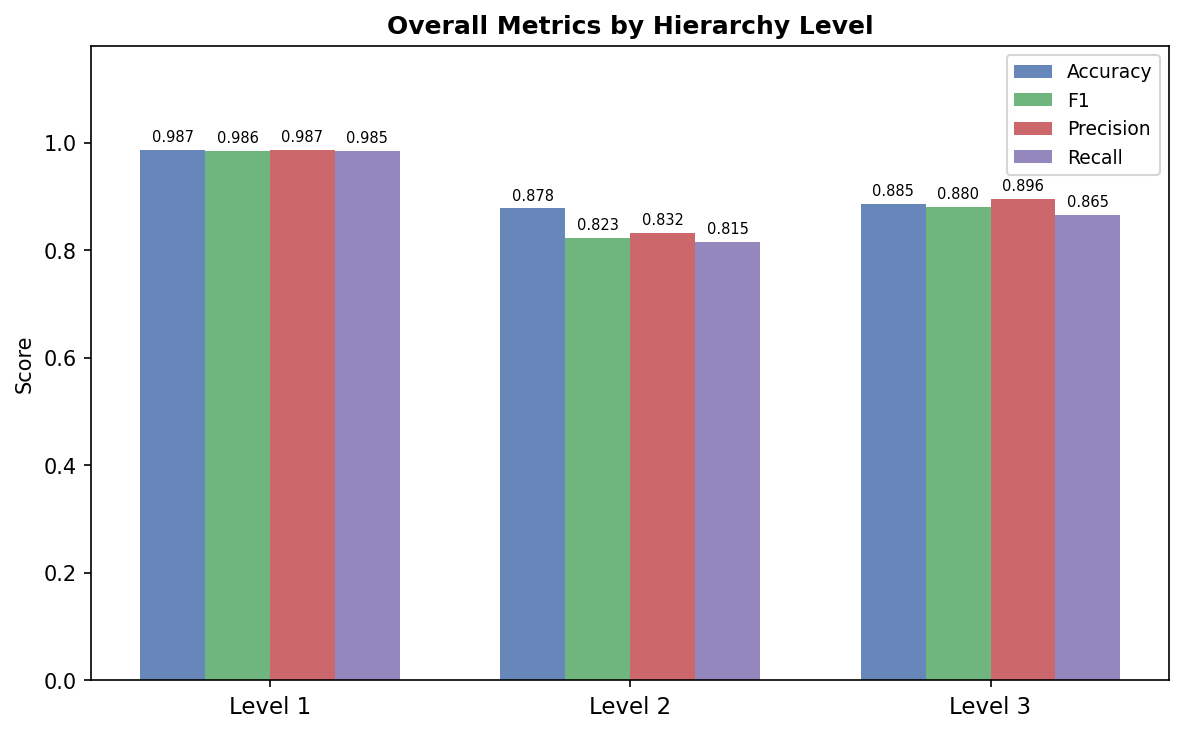

In [30]:
display(Image('efficient_net_2026-03-06/level_comparison.png', width=500))

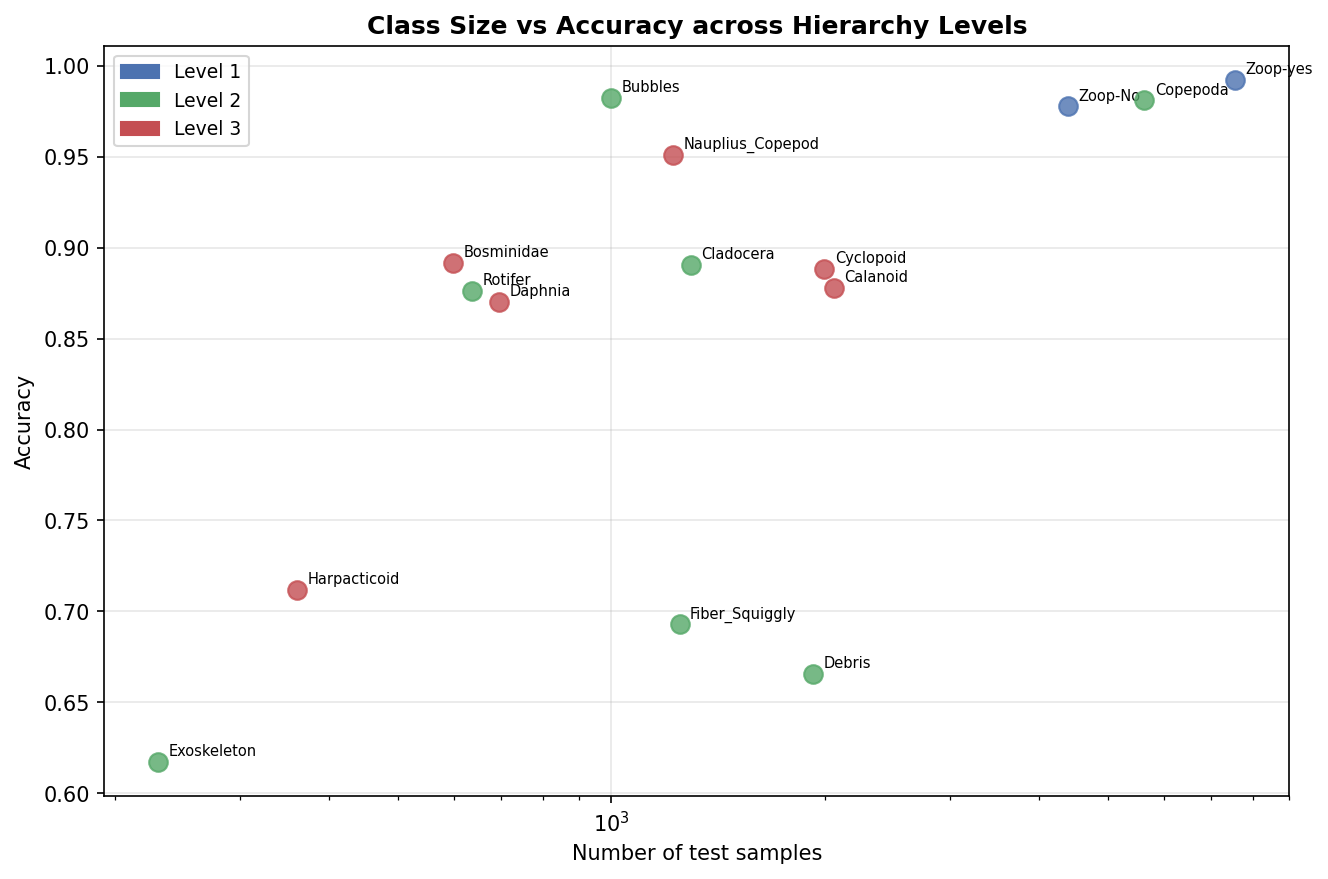

In [23]:
display(Image('efficient_net_2026-03-06/size_vs_accuracy.png', width=800))

### Cross-level accuracy pattern

| Level | Description | Accuracy | Macro F1 |
|---|---|---|---|
| 1 | Zooplankton vs. Not | 98.66% | 98.56% |
| 2 | Order | 87.79% | 82.25% |
| 3 | Species | 88.55% | 88.00% |

Accuracy drops sharply from level 1 to level 2, driven by the visually ambiguous non-zooplankton classes (Debris, Exoskeleton, Fiber_Squiggly). Level 3 slightly outperforms level 2 in accuracy — this is expected because level 3 only evaluates the zooplankton subtree (excluding the noisy non-zooplankton classes), and the zooplankton species are more morphologically separable than the debris categories.

### Sample size vs. accuracy

The `size_vs_accuracy.png` plot shows a clear positive correlation between class size and per-class accuracy across all levels. Rare classes (Harpacticoid n=361, Exoskeleton n=230) consistently underperform larger classes. This is a classic long-tail problem in multi-class classification and suggests targeted interventions for rare classes (weighted sampling, augmentation, or class-balanced loss).

---
## 11. Discussion & Next Steps

### Strengths

- **Perfect structural consistency**: 0 hierarchy mismatches across all 11,962 predictions — the HardRouter architecture guarantees this by construction
- **Strong level-1 performance**: 98.66% accuracy — the model reliably distinguishes zooplankton from non-zooplankton
- **Good leaf-level accuracy**: 88.55% macro accuracy at the species level despite 13 classes and limited training data
- **Fast convergence**: reached >82% val accuracy in just 20 epochs with no early stopping

### Weaknesses

- **Rare classes underperform**: Harpacticoid (71.19%, n=361 test) and Exoskeleton (61.74%, n=230 test) are bottlenecks for macro F1
- **Non-zooplankton ambiguity**: Debris, Fiber_Squiggly, and Exoskeleton are visually similar irregular particles — the model frequently confuses them at level 2
- **Error propagation**: a wrong routing decision at an upper node forecloses correct predictions at all lower nodes (cascade failure)

### Possible next steps

| Idea | Targets |
|---|---|
| Weighted/oversampled training for rare classes | Harpacticoid, Exoskeleton |
| Additional augmentation for rare classes | Harpacticoid, Exoskeleton |
| Longer training (>20 epochs) or lower lr | Overall convergence |
| Hyperparameter search (lr, batch size, backbone) | Overall |
| Compare against BCNN baseline on same test set | Fairness of comparison |
| Soft-routing at inference (thresholded) | Level-2 ambiguous classes |
| Error analysis on Debris/Fiber/Exoskeleton | Level-2 weak classes |